## question 1 : implement sampling and quantisation techniques for the given speech signals

- plot time domain representation of the original speech signal
- sample the speech signal at different sampling rates (eg., 8kHz, 16khZ, and 44.1kHz)
- plot sampled speech signal for each of these sampling rates
- using the above sampled signals, re-construct the signal using zero-order hold, and linear interpolation
- calculate the mean squared error between the original and the reconstructed signals for both methods

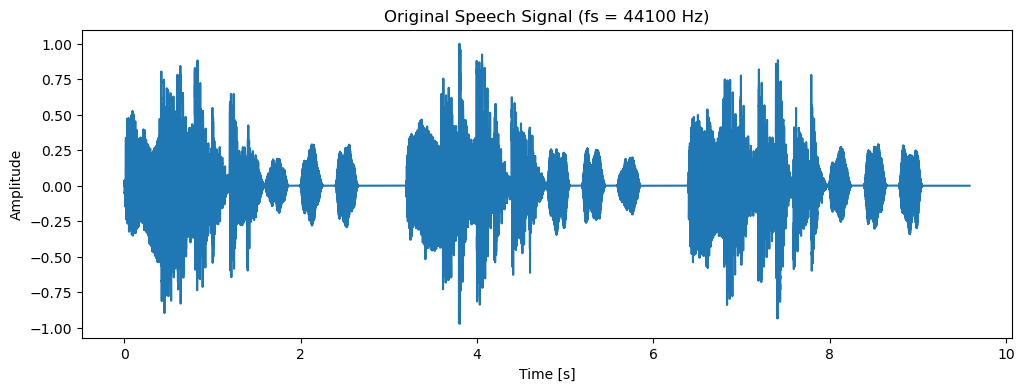

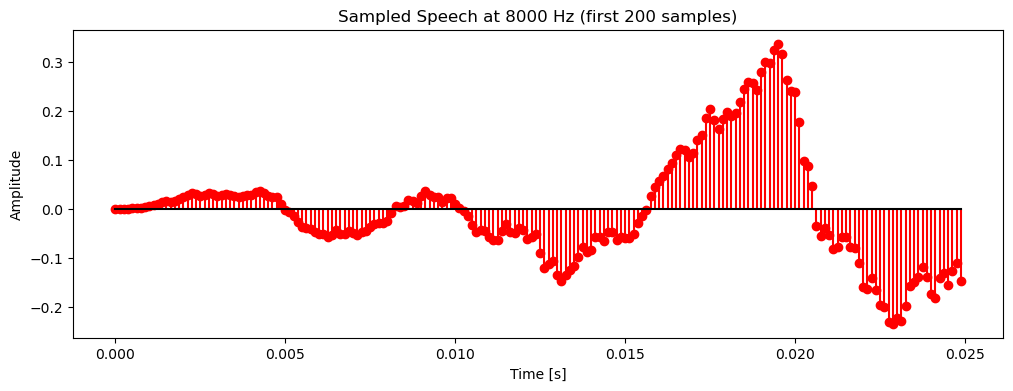

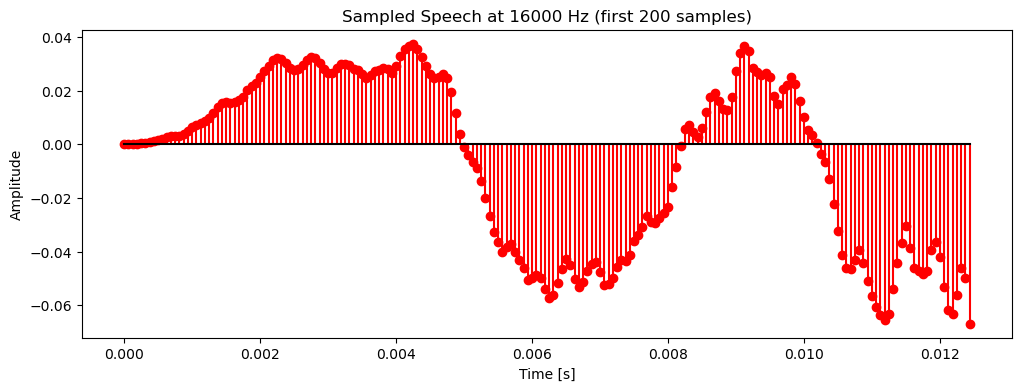

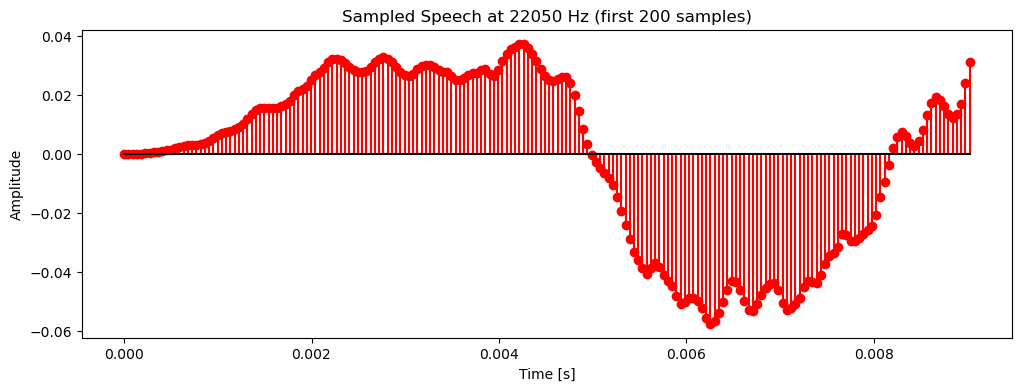

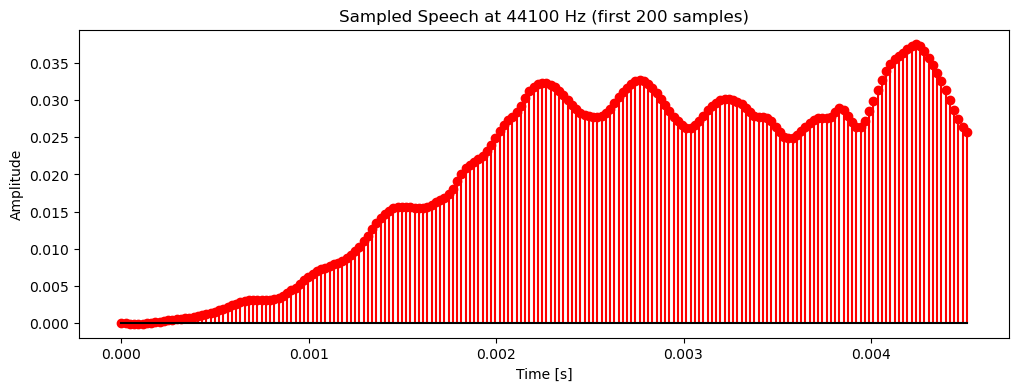

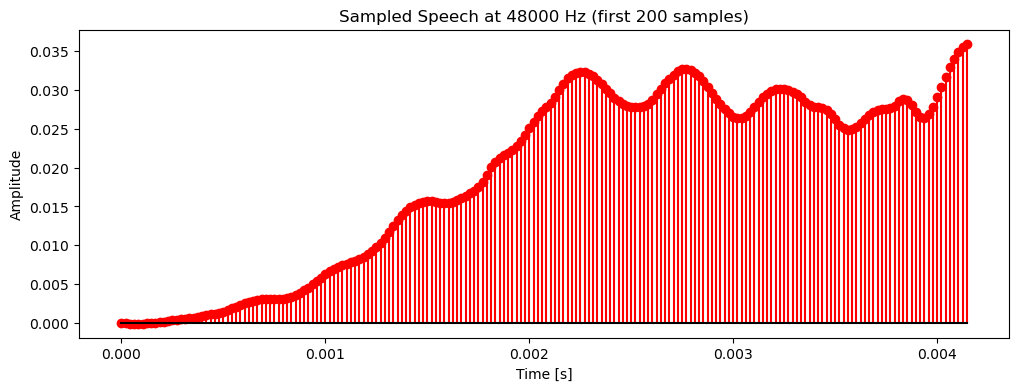

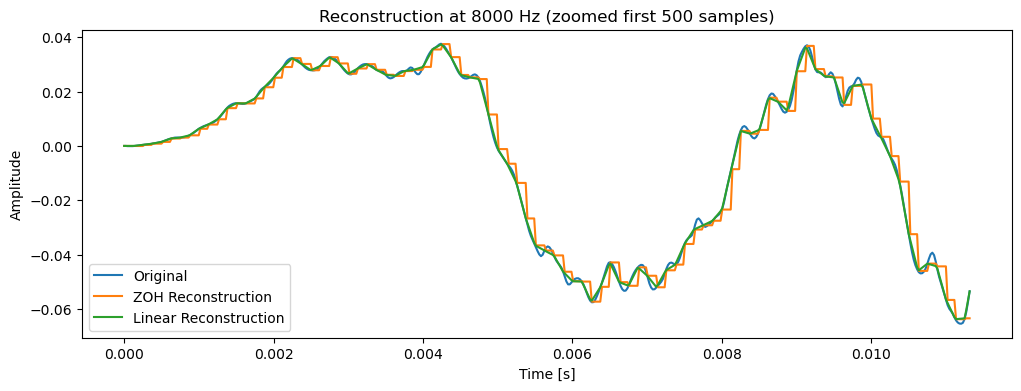

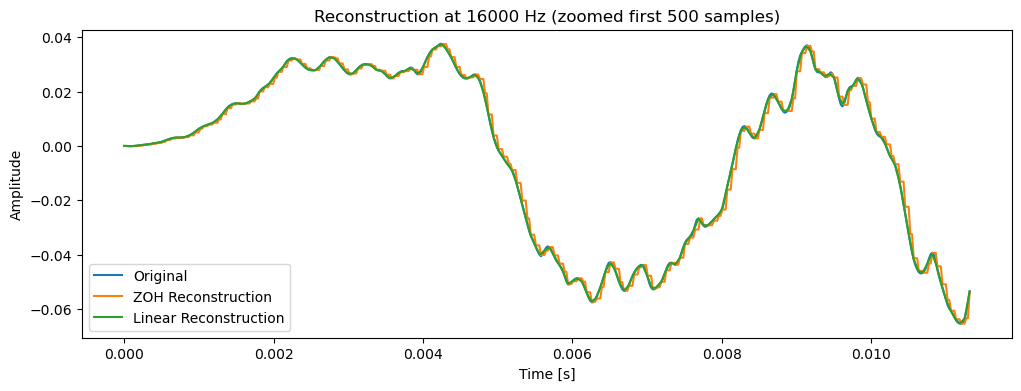

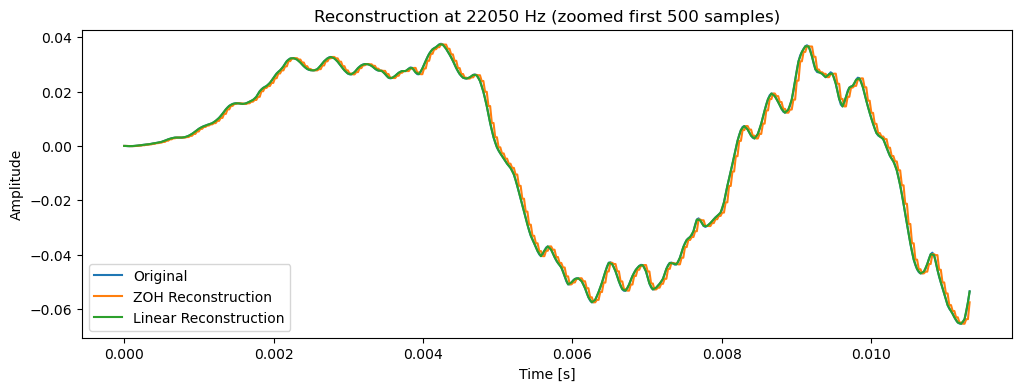

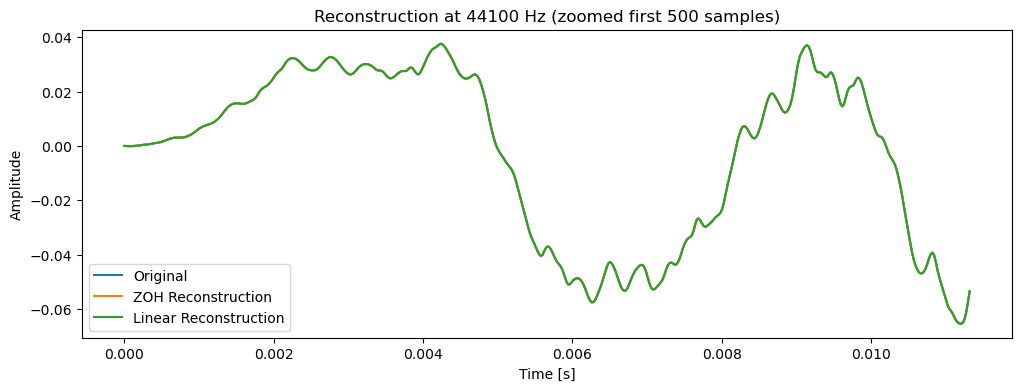

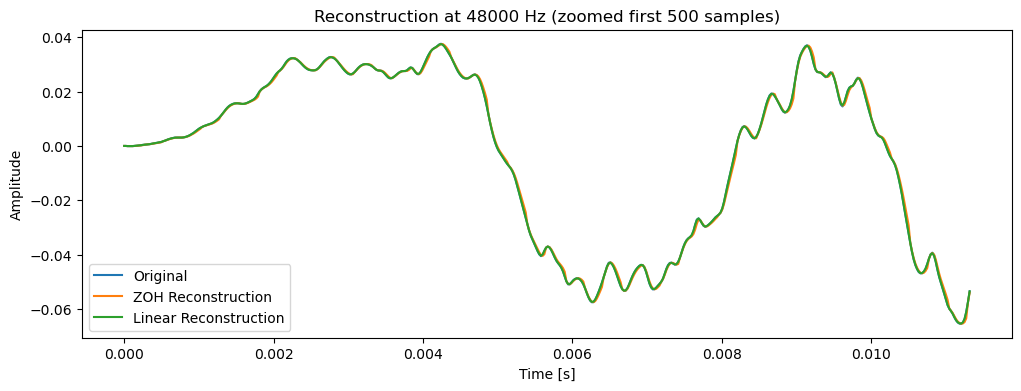

MSE Results for different sampling rates:
8000 Hz: ZOH = 0.001047, Linear = 0.000153
16000 Hz: ZOH = 0.000156, Linear = 0.000040
22050 Hz: ZOH = 0.000249, Linear = 0.000034
44100 Hz: ZOH = 0.000000, Linear = 0.000000
48000 Hz: ZOH = 0.000016, Linear = 0.000028


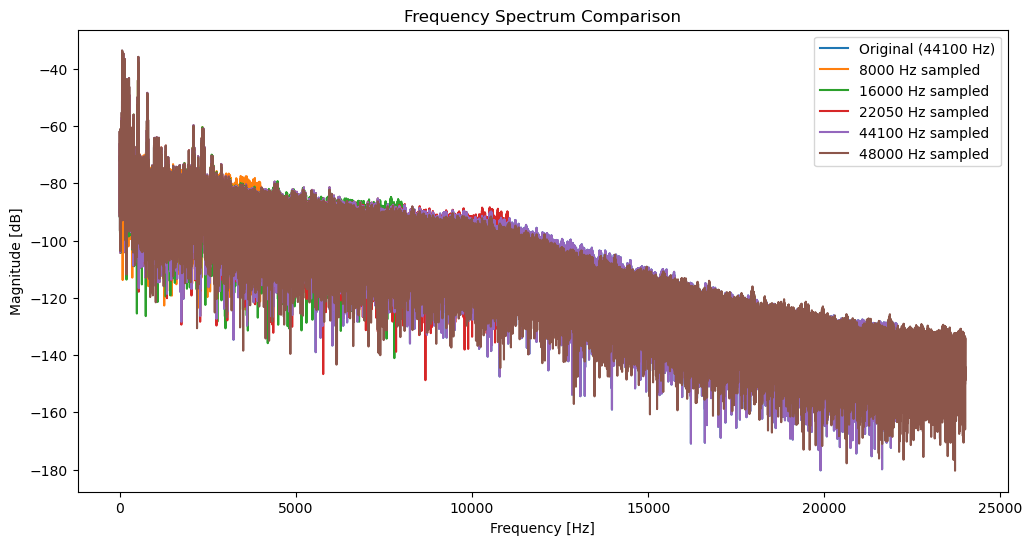

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# --- Load Audio ---
fs_original, speech = wavfile.read('/Users/soujanyabhat/Downloads/sample-9s.wav')

# If stereo, take first channel
if len(speech.shape) > 1:
    speech = speech[:, 0]

# Normalize
speech = speech / np.max(np.abs(speech))

# Original time axis
t_original = np.arange(len(speech)) / fs_original

# Plot original
plt.figure(figsize=(12,4))
plt.plot(t_original, speech)
plt.title(f'Original Speech Signal (fs = {fs_original} Hz)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()

# --- Downsample to different rates ---
sampling_rates = [8000, 16000, 22050, 44100, 48000]  

sampled_signals = {}
for fs in sampling_rates:
    t_new = np.arange(0, len(speech)/fs_original, 1/fs)
    sampled_signal = np.interp(t_new*fs_original, np.arange(len(speech)), speech)
    sampled_signals[fs] = sampled_signal
    
    # Plot sampled signal
    plt.figure(figsize=(12,4))
    plt.stem(t_new[:200], sampled_signal[:200], linefmt='r', markerfmt='ro', basefmt='k')
    plt.title(f'Sampled Speech at {fs} Hz (first 200 samples)')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.show()

# --- Reconstruction Methods ---
def zero_order_hold(sampled, original_len):
    """True ZOH: hold each sample constant until next one."""
    x_old = np.arange(len(sampled))
    x_new = np.linspace(0, len(sampled)-1, original_len)
    zoh_signal = sampled[np.floor(x_new).astype(int)]
    return zoh_signal

def linear_interpolation(sampled, original_len):
    """Standard linear interpolation reconstruction."""
    x_old = np.arange(len(sampled))
    x_new = np.linspace(0, len(sampled)-1, original_len)
    lin_signal = np.interp(x_new, x_old, sampled)
    return lin_signal

# --- Reconstruction + MSE ---
mse_results = {}

for fs in sampling_rates:
    sampled = sampled_signals[fs]
    zoh = zero_order_hold(sampled, len(speech))
    lin = linear_interpolation(sampled, len(speech))
    
    mse_zoh = np.mean((speech - zoh)**2)
    mse_lin = np.mean((speech - lin)**2)
    mse_results[fs] = {'ZOH': mse_zoh, 'Linear': mse_lin}
    
    # Plot reconstruction zoomed into small window
    plt.figure(figsize=(12,4))
    plt.plot(t_original[:500], speech[:500], label='Original')
    plt.plot(t_original[:500], zoh[:500], label='ZOH Reconstruction')
    plt.plot(t_original[:500], lin[:500], label='Linear Reconstruction')
    plt.title(f'Reconstruction at {fs} Hz (zoomed first 500 samples)')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.show()

print("MSE Results for different sampling rates:")
for fs in sampling_rates:
    print(f"{fs} Hz: ZOH = {mse_results[fs]['ZOH']:.6f}, Linear = {mse_results[fs]['Linear']:.6f}")

# --- Frequency Spectrum Comparison ---
def plot_spectrum(signal, fs, label):
    N = len(signal)
    freqs = np.fft.rfftfreq(N, 1/fs)
    spectrum = np.abs(np.fft.rfft(signal)) / N
    plt.plot(freqs, 20*np.log10(spectrum + 1e-12), label=label)

plt.figure(figsize=(12,6))
plot_spectrum(speech, fs_original, f'Original ({fs_original} Hz)')
for fs in sampling_rates:
    plot_spectrum(sampled_signals[fs], fs, f'{fs} Hz sampled')
plt.title("Frequency Spectrum Comparison")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.legend()
plt.show()


## question 2: implement the source-filter model for a given speech signal and analyze the impact of sampling and reconstruction on the quality of the speech signal

- generate a synthetic speech signal using the source-filter model
- create a source signal (eg., a glottal pulse train for voiced sounds or white noise for unvoiced sounds)
- apply a filter that models the vocal tract, represented by an all-pole filter or an FIR filter with formants(resonances of the vocal tract)
- plot the generated speech signal and analyse the effect of the filter on the original source
- sample the speech signal generated above at different sampling rates
- reconstruct the signal using a suitable interpolation method (zero-order hold, linear interpolation)
- compute the mean-squared error (MSE) between the original and reconstructed speech signals

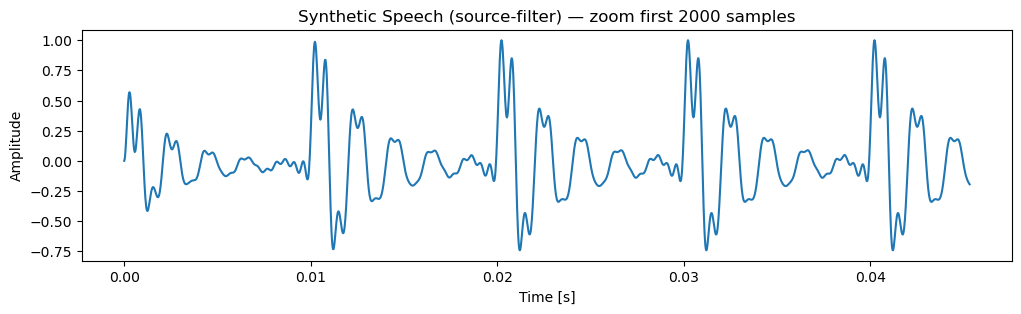

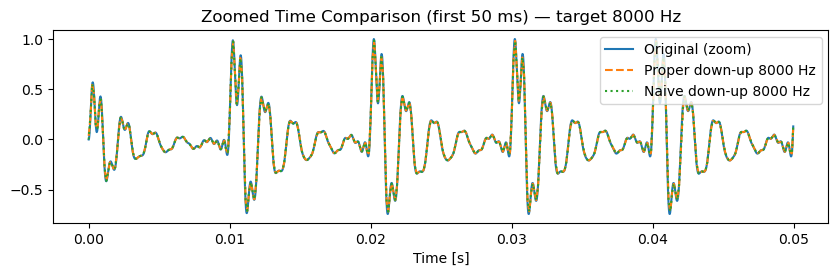

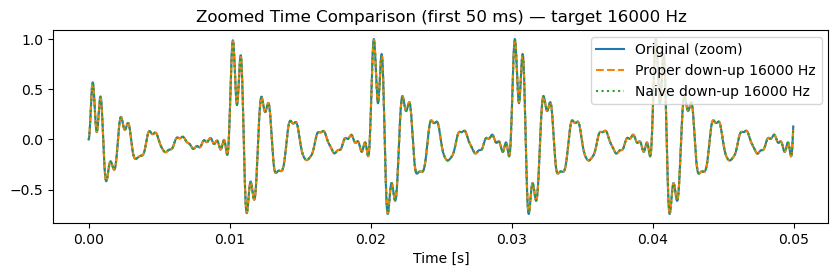

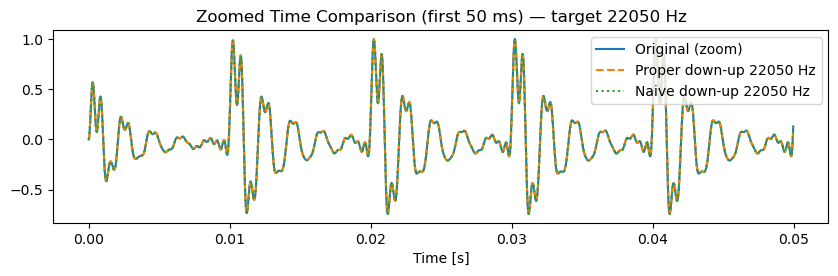

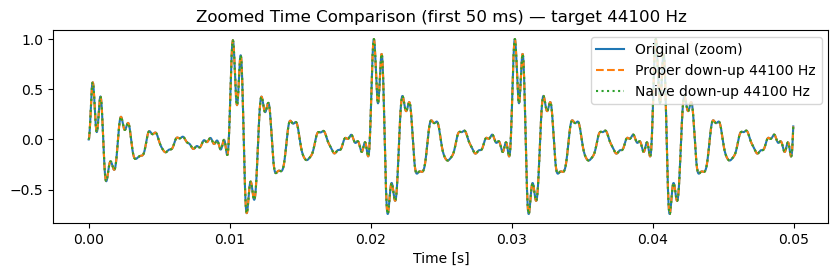

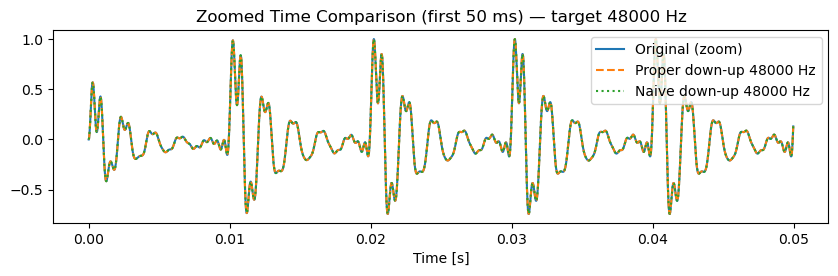

MSE Results (proper resample -> recon to original length):
8000 Hz: ZOH = 0.02714471, Linear = 0.00654404
16000 Hz: ZOH = 0.00611034, Linear = 0.00106132
22050 Hz: ZOH = 0.00260239, Linear = 0.00034845
44100 Hz: ZOH = 0.00000000, Linear = 0.00000000
48000 Hz: ZOH = 0.00025685, Linear = 0.00000251


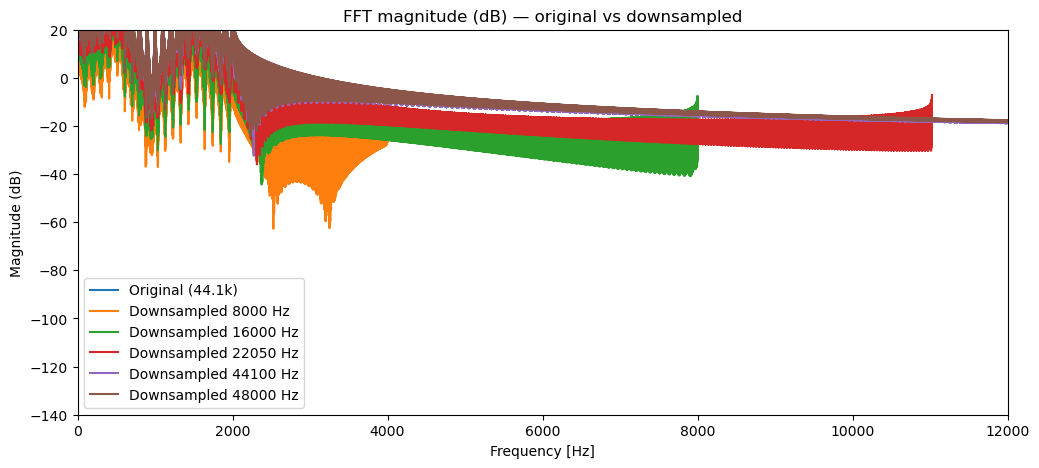

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

# -----------------------------
# Synthetic source-filter signal
# -----------------------------
duration = 0.5  # seconds
fs = 44100
t = np.arange(0, duration, 1/fs)

f0 = 100  # fundamental
# make a richer source: sum of harmonics (decaying amplitude)
num_harmonics = 20
source_signal = np.zeros_like(t)
for k in range(1, num_harmonics+1):
    source_signal += (1.0 / k) * np.sin(2*np.pi*(k*f0)*t)

# 2-formant resonators using iirpeak (narrower Q)
formants = [500, 1500]
bandwidths = [100, 200]
filtered_signal = np.zeros_like(source_signal)
for f1, bw in zip(formants, bandwidths):
    # Design bandpass-like resonator using iirpeak (approx)
    b, a = signal.iirpeak(f1 / (fs/2), Q=f1/bw)  # center freq normalized to Nyquist
    filtered_signal += signal.lfilter(b, a, source_signal)

# normalize
filtered_signal /= np.max(np.abs(filtered_signal))

# show original waveform (zoomed)
plt.figure(figsize=(12,3))
plt.plot(t[:2000], filtered_signal[:2000])
plt.title("Synthetic Speech (source-filter) — zoom first 2000 samples")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.show()

# ---------- helper recon functions ----------
def zero_order_hold(sampled, original_len):
    """True ZOH reconstruction from sampled array to original_len points"""
    x_old = np.arange(len(sampled))
    x_new = np.linspace(0, len(sampled)-1, original_len)
    zoh_signal = sampled[np.floor(x_new).astype(int)]
    return zoh_signal

def linear_interpolation(sampled, original_len):
    x_old = np.arange(len(sampled))
    x_new = np.linspace(0, len(sampled)-1, original_len)
    lin_signal = np.interp(x_new, x_old, sampled)
    return lin_signal

def plot_fft_db(sig, fs_local, label, Nfft=65536):
    # zero-pad/FFT for good resolution
    S = np.fft.rfft(sig, n=Nfft)
    freqs = np.fft.rfftfreq(Nfft, 1/fs_local)
    mag_db = 20*np.log10(np.abs(S) + 1e-12)
    plt.plot(freqs, mag_db, label=label)

def plot_spectrogram(sig, fs_local, title):
    f, tt, Sxx = signal.spectrogram(sig, fs_local, nperseg=1024, noverlap=768)
    plt.pcolormesh(tt, f, 20*np.log10(Sxx+1e-12), shading='gouraud')
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [s]')
    plt.title(title)
    plt.ylim(0, fs_local/2)
    plt.colorbar(label='Magnitude (dB)')

# ---------- sampling rates to compare ----------
sampling_rates = [8000, 16000, 22050, 44100, 48000]

# store signals
sampled_signals_proper = {}
sampled_signals_naive = {}

for fs_s in sampling_rates:
    # number of samples at new fs
    num_samples = int(len(filtered_signal) * fs_s / fs)
    # Proper resampling (uses FFT-based resample with anti-alias filtering)
    sampled_proper = signal.resample(filtered_signal, num_samples)
    sampled_signals_proper[fs_s] = sampled_proper

    # Naive sampling via linear interpolation (no anti-aliasing)
    t_new = np.arange(0, len(filtered_signal)/fs, 1/fs_s)
    sampled_naive = np.interp(t_new * fs, np.arange(len(filtered_signal)), filtered_signal)
    sampled_signals_naive[fs_s] = sampled_naive

    # plot a small region of sampled points to compare naive vs proper
    plt.figure(figsize=(10,2.5))
    # time axes for the zoomed region (~ first 50 ms)
    zoom_len = int(0.05 * fs)  # first 50 ms of original
    t_zoom = np.arange(zoom_len) / fs
    # reconstruct naive & proper back to original length via linear interp for plotting convenience
    recon_naive = linear_interpolation(sampled_naive, len(filtered_signal))
    recon_proper = linear_interpolation(sampled_proper, len(filtered_signal))
    plt.plot(t_zoom, filtered_signal[:zoom_len], label='Original (zoom)')
    plt.plot(t_zoom, recon_proper[:zoom_len], '--', label=f'Proper down-up {fs_s} Hz')
    plt.plot(t_zoom, recon_naive[:zoom_len], ':', label=f'Naive down-up {fs_s} Hz')
    plt.title(f'Zoomed Time Comparison (first 50 ms) — target {fs_s} Hz')
    plt.xlabel('Time [s]')
    plt.legend()
    plt.show()

# ---------- Reconstruction and MSE (use proper downsampled signals) ----------
mse_results_sfm = {}
for fs_s in sampling_rates:
    sampled = sampled_signals_proper[fs_s]
    # reconstruct to original length
    recon_zoh = zero_order_hold(sampled, len(filtered_signal))
    recon_lin = linear_interpolation(sampled, len(filtered_signal))
    mse_zoh = np.mean((filtered_signal - recon_zoh)**2)
    mse_lin = np.mean((filtered_signal - recon_lin)**2)
    mse_results_sfm[fs_s] = {'ZOH': mse_zoh, 'Linear': mse_lin}

print("MSE Results (proper resample -> recon to original length):")
for fs_s in sampling_rates:
    print(f"{fs_s} Hz: ZOH = {mse_results_sfm[fs_s]['ZOH']:.8f}, Linear = {mse_results_sfm[fs_s]['Linear']:.8f}")

# ---------- FFT comparison ----------
plt.figure(figsize=(12,5))
plot_fft_db(filtered_signal, fs, 'Original (44.1k)')
for fs_s in sampling_rates:
    # plot FFT of the downsampled signals with their own fs so Nyquist changes are visible
    s_down = sampled_signals_proper[fs_s]
    plot_fft_db(s_down, fs_s, f'Downsampled {fs_s} Hz')
plt.xlim(0, 12000)  # focus to 12 kHz region (speech-relevant)
plt.ylim(-140, 20)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude (dB)')
plt.title('FFT magnitude (dB) — original vs downsampled')
plt.legend()
plt.show()

